# 04 — Generate Submission
**March Madness 2026**

In [57]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

from src.features import build_matchup_df
from src.model import LogisticBaseline, MarchMadnessNet

DATA_DIR = Path('../data/raw')
PROC_DIR = Path('../data/processed')
OUT_DIR  = Path('../outputs')

## 1. Load Model Selection Results

In [58]:
with open(PROC_DIR / 'model_results.json') as f:
    results = json.load(f)

#print(json.dumps(results, indent=2))

m_best = results['M']['best_model']
w_best  = results['W']['best_model']
m_diff_cols = results['M']['diff_cols']
w_diff_cols = results['W']['diff_cols']

print(f"\nUsing for Mens: {m_best}")
print(f"Using for Womens: {w_best}")


Using for Mens: nn
Using for Womens: logreg


In [59]:
m_feats = pd.read_csv(PROC_DIR / 'M_team_features.csv')
w_feats = pd.read_csv(PROC_DIR / 'W_team_features.csv')

# Rebuild prediction matchups with gender filter and cleaned feature set
m_pred_df, m_diff_cols = build_matchup_df(m_feats, gender='M', mode='predict')
w_pred_df, w_diff_cols = build_matchup_df(w_feats, gender='W', mode='predict')

print(f"\nMens 2026 matchups:   {m_pred_df.shape}  (should be ~66k)")
print(f"Womens 2026 matchups: {w_pred_df.shape}  (should be ~66k)")
print(f"\nMens diff features ({len(m_diff_cols)}): {m_diff_cols}")
print(f"\nWomens diff features ({len(w_diff_cols)}): {w_diff_cols}")

# Resave updated diff cols
with open(PROC_DIR / 'M_diff_cols.json', 'w') as f:
    json.dump(m_diff_cols, f)
with open(PROC_DIR / 'W_diff_cols.json', 'w') as f:
    json.dump(w_diff_cols, f)

[M] Matchup df shape: (66430, 62)  |  diff features: 19
[W] Matchup df shape: (65703, 53)  |  diff features: 16

Mens 2026 matchups:   (66430, 62)  (should be ~66k)
Womens 2026 matchups: (65703, 53)  (should be ~66k)

Mens diff features (19): ['diff_PointsFor', 'diff_PointsAgn', 'diff_WinPct', 'diff_ASTpg', 'diff_TOpg', 'diff_STLpg', 'diff_BLKpg', 'diff_FGpct', 'diff_FG3pct', 'diff_PointDiff', 'diff_eFG_pct', 'diff_TOV_pct', 'diff_ORB_pct', 'diff_FTR', 'diff_Def_eFG_pct', 'diff_rank_MAS', 'diff_rank_MOR', 'diff_rank_POM', 'diff_SeedNum']

Womens diff features (16): ['diff_PointsFor', 'diff_PointsAgn', 'diff_WinPct', 'diff_ASTpg', 'diff_TOpg', 'diff_STLpg', 'diff_BLKpg', 'diff_FGpct', 'diff_FG3pct', 'diff_PointDiff', 'diff_eFG_pct', 'diff_TOV_pct', 'diff_ORB_pct', 'diff_FTR', 'diff_Def_eFG_pct', 'diff_SeedNum']


## 2. Load Saved Models

Need to refer back to phase 3 to pull proper models used.

In [60]:
# if m_best == 'nn':
#     m_model = MarchMadnessNet(hidden_dims=[128, 64, 32], dropout=0.3)
#     m_model.load(tag = 'M', input_dim = len(m_diff_cols))
# else:
#     m_model = LogisticBaseline()
#     m_model.load(tag='M')

# just always using neural network
m_model = MarchMadnessNet(hidden_dims = [256, 128, 64], dropout = 0.15,
                       lr = 1e-4, weight_decay = .005,
                       batch_size = 64, max_epochs = 200,
                       patience = 50)
m_model.load(tag = 'M', input_dim = len(m_diff_cols))

# print(f"Mens model loaded: {m_best}")

# if w_best == 'nn':
#     w_model = MarchMadnessNet(hidden_dims=[64, 32], dropout=0.3)
#     w_model.load(tag='W', input_dim=len(w_diff_cols))
# else:
#     w_model = LogisticBaseline()
#     w_model.load(tag='W')

w_model = MarchMadnessNet(hidden_dims = [128, 128, 32], dropout = 0.2,
                       lr = 1e-4, weight_decay = 1e-3,
                       batch_size = 64, max_epochs = 200,
                       patience = 50)
w_model.load(tag = 'W', input_dim = len(w_diff_cols))

# print(f"Womens model loaded: {w_best}")

Using Apple MPS (GPU)
Model M loaded successfully
Using Apple MPS (GPU)
Model W loaded successfully


## 3. Load 2026 Prediction Matchups

In [61]:
m_pred_df = pd.read_csv(PROC_DIR / 'M_matchup_predict.csv')
w_pred_df = pd.read_csv(PROC_DIR / 'W_matchup_predict.csv')

print(f"Mens 2026 matchups:   {m_pred_df.shape}")
print(f"Womens 2026 matchups: {w_pred_df.shape}")

m_miss = m_pred_df[m_diff_cols].isnull().mean()
print(f"\nMens: {(m_miss > 0).sum()} features with missing values")
print(m_miss[m_miss > 0].sort_values(ascending=False).to_string())

Mens 2026 matchups:   (66430, 62)
Womens 2026 matchups: (65703, 53)

Mens: 0 features with missing values
Series([], )


## 4. Run Predictions

The preprocessor (fitted on training data) handles imputation of any
remaining missing values using training-set medians.

The Stage 2 submission includes ALL possible 2026 matchup pairs (132,133
rows), not just the actual tournament bracket. Kaggle scores only the
games that are actually played.

In [62]:
m_X_pred = m_pred_df[m_diff_cols].values
m_probs  = m_model.predict_proba(m_X_pred)

print(f"Mens predictions: {m_probs.shape}")
print(f"  Min={m_probs.min():.4f}  Max={m_probs.max():.4f}  Mean={m_probs.mean():.4f}")

w_X_pred = w_pred_df[w_diff_cols].values
w_probs  = w_model.predict_proba(w_X_pred)

print(f"Womens predictions: {w_probs.shape}")
print(f"  Min={w_probs.min():.4f}  Max={w_probs.max():.4f}  Mean={w_probs.mean():.4f}")

Mens predictions: (66430,)
  Min=0.0006  Max=0.9970  Mean=0.4689
Womens predictions: (65703,)
  Min=0.0330  Max=0.9875  Mean=0.5276


## 5. Build Submission DataFrame

In [63]:
m_sub = pd.DataFrame({'ID':   m_pred_df['ID'].values,
                      'Pred': m_probs})

w_sub = pd.DataFrame({'ID':   w_pred_df['ID'].values,
                      'Pred': w_probs})

submission = pd.concat([m_sub, w_sub], ignore_index=True)
submission['Pred'] = submission['Pred'].fillna(0.5)


print(f"Combined submission shape: {submission.shape}")
print(f"\nFirst 5 rows:")
print(submission.head())
print(f"\nLast 5 rows:")
print(submission.tail())

Combined submission shape: (132133, 2)

First 5 rows:
               ID      Pred
0  2026_1101_1102  0.885916
1  2026_1101_1103  0.073024
2  2026_1101_1104  0.035675
3  2026_1101_1105  0.806222
4  2026_1101_1106  0.703045

Last 5 rows:
                    ID      Pred
132128  2026_3478_3480  0.321600
132129  2026_3478_3481  0.302378
132130  2026_3479_3480  0.222982
132131  2026_3479_3481  0.208626
132132  2026_3480_3481  0.587684


## 6. Validate Against Sample Submission

In [64]:
print(f"Combined submission shape: {submission.shape}")

# Validate against Stage 2 sample
sample = pd.read_csv(DATA_DIR / 'SampleSubmissionStage2.csv')
print(f"\n=== Validation ===")
assert len(submission) == len(sample), \
    f"Row count mismatch: {len(submission)} vs {len(sample)}"
print(f"Row count matches: {len(submission)}")

missing_ids = set(sample['ID']) - set(submission['ID'])
extra_ids   = set(submission['ID']) - set(sample['ID'])
print(f"Missing IDs: {len(missing_ids)}")
print(f"Extra IDs:   {len(extra_ids)}")

assert submission['Pred'].between(0, 1).all()
print(f"All predictions in [0, 1]")
print(f"NaN predictions: {submission['Pred'].isna().sum()}")

print(f"\nPrediction distribution:")
print(submission['Pred'].describe())

Combined submission shape: (132133, 2)

=== Validation ===
Row count matches: 132133
Missing IDs: 0
Extra IDs:   0
All predictions in [0, 1]
NaN predictions: 0

Prediction distribution:
count    132133.000000
mean          0.498081
std           0.258878
min           0.000583
25%           0.321566
50%           0.523221
75%           0.684132
max           0.997001
Name: Pred, dtype: float64


## 7. Prediction Distribution Plot

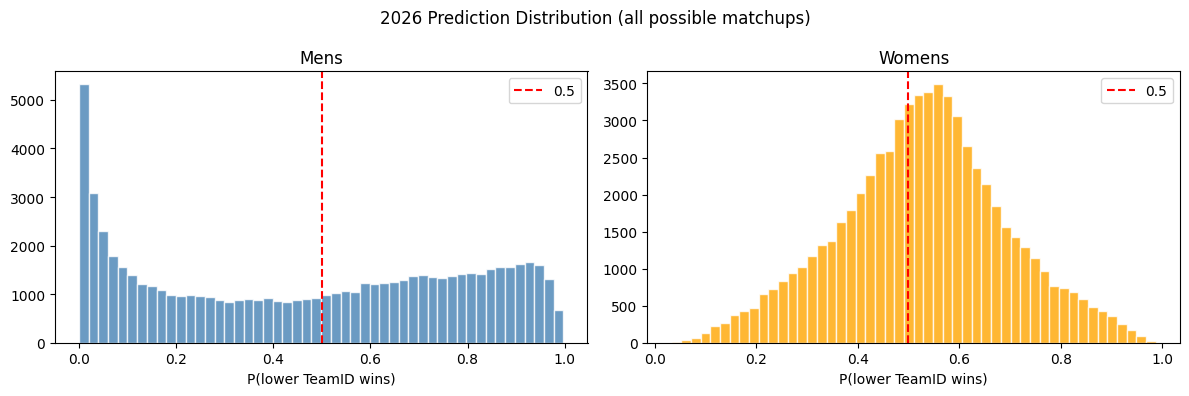

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('2026 Prediction Distribution (all possible matchups)')

axes[0].hist(m_probs, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', label='0.5')
axes[0].set_title("Mens")
axes[0].set_xlabel('P(lower TeamID wins)')
axes[0].legend()

axes[1].hist(w_probs, bins=50, color='orange', edgecolor='white', alpha=0.8)
axes[1].axvline(0.5, color='red', linestyle='--', label='0.5')
axes[1].set_title("Womens")
axes[1].set_xlabel('P(lower TeamID wins)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/prediction_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# Team look-up checker

In [66]:
m_teams = pd.read_csv(DATA_DIR / 'MTeams.csv')
w_teams = pd.read_csv(DATA_DIR / 'WTeams.csv')
all_teams = pd.concat([m_teams, w_teams], ignore_index=True)

# Dict: TeamID -> TeamName
team_lookup = dict(zip(all_teams['TeamID'], all_teams['TeamName']))

def lookup_team(team_id):
    return team_lookup.get(int(team_id), f'Unknown({team_id})')

def decode_matchup_id(matchup_id):
    parts     = matchup_id.split('_')
    season    = parts[0]
    team_a    = lookup_team(parts[1])
    team_b    = lookup_team(parts[2])
    return f"{season}: {team_a} (lower ID) vs {team_b} (higher ID)"

print(f"Teams loaded: {len(team_lookup)}")
print("\nExample lookups:")
print(decode_matchup_id('2026_1101_1102'))
print(decode_matchup_id('2026_3478_3480'))

Teams loaded: 760

Example lookups:
2026: Abilene Chr (lower ID) vs Air Force (higher ID)
2026: Le Moyne (lower ID) vs West Georgia (higher ID)


In [67]:
# Add team name columns to the submission for easy inspection
def enrich_submission(sub_df, pred_df):
    enriched = sub_df.copy()
    parts = enriched['ID'].str.split('_', expand=True)
    enriched['Season'] = parts[0].astype(int)
    enriched['TeamA_ID'] = parts[1].astype(int)
    enriched['TeamB_ID'] = parts[2].astype(int)
    enriched['TeamA_Name'] = enriched['TeamA_ID'].map(team_lookup)
    enriched['TeamB_Name'] = enriched['TeamB_ID'].map(team_lookup)
    enriched['P_A_wins'] = enriched['Pred'].round(4)
    enriched['P_B_wins'] = (1 - enriched['Pred']).round(4)
    return enriched[['ID','TeamA_Name','TeamA_ID','TeamB_Name','TeamB_ID',
                      'P_A_wins','P_B_wins']]

m_enriched = enrich_submission(m_sub, m_pred_df)
w_enriched = enrich_submission(w_sub, w_pred_df)

all_enriched = pd.concat([m_enriched, w_enriched], ignore_index=True)
#print(f"Enriched lookup table: {all_enriched.shape}")
#all_enriched.head(10)

In [81]:
def matchup_prob_checker(team_a, team_b, gender="M"):
    if gender == "W":
        df = all_enriched[all_enriched['TeamA_ID'] > 2001]
    else:
        df = all_enriched[all_enriched['TeamA_ID'] < 2001]

    # Swap if team_a has a higher ID than team_b
    id_a = all_enriched.loc[all_enriched['TeamA_Name'] == team_a, 'TeamA_ID'].iloc[0]
    id_b = all_enriched.loc[all_enriched['TeamB_Name'] == team_b, 'TeamB_ID'].iloc[0]
    if id_a > id_b:
        team_a, team_b = team_b, team_a

    return df[(df["TeamA_Name"] == team_a) & (df["TeamB_Name"] == team_b)]

team_a = "Georgia"
team_b = "Akron"

matchup_prob_checker(team_a, team_b)

,ID,TeamA_Name,TeamA_ID,TeamB_Name,TeamB_ID,P_A_wins,P_B_wins
825,2026_1103_1208,Akron,1103,Georgia,1208,0.4967,0.5033


## 8. Save Submission File

In [70]:
out_path = OUT_DIR / 'submission.csv'
submission.to_csv(out_path, index=False)
print(f"Submission saved to {out_path}")
print(f"Shape: {submission.shape}")
print(submission.head(10).to_string())

Submission saved to ../outputs/submission.csv
Shape: (132133, 2)
               ID      Pred
0  2026_1101_1102  0.885916
1  2026_1101_1103  0.073024
2  2026_1101_1104  0.035675
3  2026_1101_1105  0.806222
4  2026_1101_1106  0.703045
5  2026_1101_1107  0.708816
6  2026_1101_1108  0.861227
7  2026_1101_1110  0.619551
8  2026_1101_1111  0.448829
9  2026_1101_1112  0.034722


## 9. Upload to Kaggle

Run these commands in your terminal (not here in the notebook).

**Stage 2 submission (actual 2026 predictions):**
```bash
cd ~/Desktop/MM_26
source venv/bin/activate
kaggle competitions submit -c march-machine-learning-mania-2026 -f outputs/submission.csv -m "Baseline: LogReg + NN on box stats + Massey ordinals"
```

After uploading, go to kaggle.com, open My Submissions, and manually
select this as one of your two scored submissions. The score will show
0.0 until the 2026 tournament is played — that is expected.

**Stage 1 submission (scores immediately against 2022-2025 results):**
```bash
kaggle competitions submit -c march-machine-learning-mania-2026 -f outputs/submission_stage1.csv -m "Stage 1 validation"
```

## 10. (Optional) Stage 1 Validation Submission

Generate predictions for 2022-2025 to get an immediate leaderboard score.

In [71]:
from src.features import _parse_matchup_id

stage1 = pd.read_csv(DATA_DIR / 'SampleSubmissionStage1.csv')
print(f"Stage 1 rows: {len(stage1)}")
print(stage1.head())

parsed = stage1['ID'].apply(_parse_matchup_id)
s1_df  = pd.DataFrame(parsed.tolist(), columns=['Season', 'TeamA', 'TeamB'])
s1_df['ID'] = stage1['ID'].values

print("\nStage 1 seasons:", sorted(s1_df['Season'].unique()))

Stage 1 rows: 519144
               ID  Pred
0  2022_1101_1102   0.5
1  2022_1101_1103   0.5
2  2022_1101_1104   0.5
3  2022_1101_1105   0.5
4  2022_1101_1106   0.5

Stage 1 seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [72]:
s1_df['is_mens'] = s1_df['TeamA'] < 3000

m_feats_df = pd.read_csv(PROC_DIR / 'M_team_features.csv')
w_feats_df = pd.read_csv(PROC_DIR / 'W_team_features.csv')

def predict_from_source(source_df, team_feats, diff_cols, model):
    feat_cols = [c for c in team_feats.columns if c not in ['Season', 'TeamID']]
    tf_a = team_feats.rename(columns={'TeamID': 'TeamA',
                                       **{c: f'A_{c}' for c in feat_cols}})
    tf_b = team_feats.rename(columns={'TeamID': 'TeamB',
                                       **{c: f'B_{c}' for c in feat_cols}})
    df = source_df.merge(tf_a, on=['Season', 'TeamA'], how='left')
    df = df.merge(tf_b, on=['Season', 'TeamB'], how='left')
    for col in feat_cols:
        df[f'diff_{col}'] = df[f'A_{col}'] - df[f'B_{col}']
    X = df[diff_cols].values
    return model.predict_proba(X)

m_s1 = s1_df[s1_df['is_mens']].copy()
w_s1 = s1_df[~s1_df['is_mens']].copy()

m_s1_probs = predict_from_source(m_s1, m_feats_df, m_diff_cols, m_model)
w_s1_probs = predict_from_source(w_s1, w_feats_df, w_diff_cols, w_model)

m_s1 = m_s1.copy()
w_s1 = w_s1.copy()
m_s1['Pred'] = m_s1_probs
w_s1['Pred'] = w_s1_probs

s1_sub = pd.concat([m_s1[['ID', 'Pred']], w_s1[['ID', 'Pred']]])
s1_sub['Pred'] = s1_sub['Pred'].fillna(0.5)

s1_out = OUT_DIR / 'submission_stage1.csv'
s1_sub.to_csv(s1_out, index=False)
print(f"Stage 1 submission saved to {s1_out}")
print(f"Shape: {s1_sub.shape}")

Stage 1 submission saved to ../outputs/submission_stage1.csv
Shape: (519144, 2)


## Summary

You now have two submission files ready:

| File | Purpose |
|------|---------|
| outputs/submission.csv | Stage 2 - actual 2026 predictions, scored after tournament |
| outputs/submission_stage1.csv | Stage 1 - 2022-2025 historical, scores immediately |

Upload Stage 1 first to get an immediate leaderboard score and verify
the pipeline is working end-to-end.

Next steps after submission:
- Review Stage 1 leaderboard score vs our local val Brier
- Feature engineering improvements (conference, coaching, travel distance)
- Hyperparameter tuning (NN architecture, regularisation strength)
- Ensemble: average LogReg and NN predictions